Importing the Dependencies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix
import tensorflow as tf
tf.random.set_seed(3)

Loading the MNIST data from keras.dataset

In [2]:
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

In [3]:
type(X_train)

numpy.ndarray

In [4]:
# shapes of the numpy arrays
print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


Training Data = 60000 Grayscaled images

Test Data = 10000 Grayscaled images

All images are of 28 x 28

In [5]:
# printing the 7th image

print(X_train[6])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 145 255 211  31   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  32 237 253 252  71   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  11 175 253 252  71   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 144 253 252  71   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  16 191 253 252  7

In [6]:
X_train[6].shape

(28, 28)

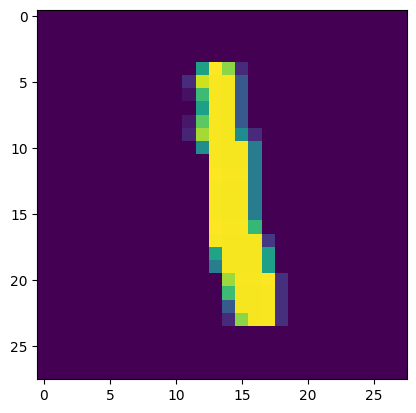

1


In [7]:
# displaying the image
plt.imshow(X_train[6])
plt.show()

# printing the corresponding label
print(Y_train[6])

Image Labels

In [8]:
# unique values in Y_train
np.unique(Y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [9]:
np.unique(Y_test)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

No need to resize the images as dimension of all the iamges is  same

In [10]:
# scaling the data for standardization

X_train = X_train / 255
X_test = X_test / 255

In [11]:
X_train[10]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

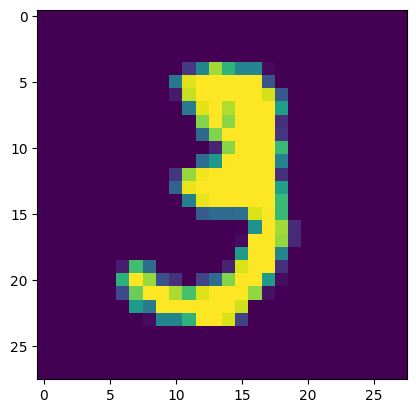

In [12]:
plt.imshow(X_train[10])
plt.show()

Building the Neural Network

In [13]:
# setting up the layers of the Neural Network
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(50, activation='relu'),
    keras.layers.Dense(50, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid') # 10 --> 0 - 9 i.e output classes
])

c:\Users\prasi\Documents\code\ml_projects\dl_projects\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
# compiling the neural network

model.compile(optimizer='adam', loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])

In [15]:
# training the model

model.fit(X_train, Y_train, epochs=15)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 995us/step - accuracy: 0.9125 - loss: 0.2973
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 982us/step - accuracy: 0.9596 - loss: 0.1335
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 940us/step - accuracy: 0.9695 - loss: 0.0998
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 964us/step - accuracy: 0.9761 - loss: 0.0796
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9805 - loss: 0.0659
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9837 - loss: 0.0554
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9860 - loss: 0.0473
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9882 - loss: 0.0404
Epoch 9/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9897 - loss: 0.0349
Epoch 10/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9902 - loss: 0.0317
Epoch 11/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9915 - loss: 0.0276
Epoch 12/15
1875/1875 

Training Data accuracy is 99.22%\
Test Data Accuracy:

In [16]:
loss, accuracy = model.evaluate(X_test, Y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 952us/step - accuracy: 0.9686 - loss: 0.1489


In [17]:
accuracy

0.9685999751091003

In [18]:
loss

0.1488810032606125

So, Test Data Accuracy is 96.81%

In [19]:
X_test.shape

(10000, 28, 28)

7


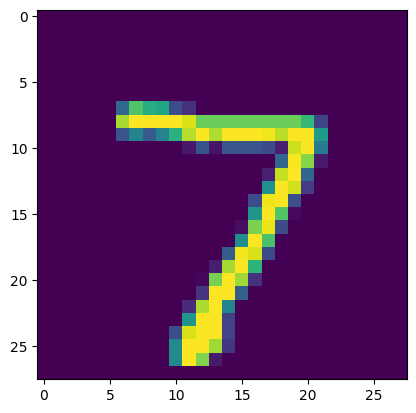

In [20]:
# first data point in X_test
plt.imshow(X_test[0])
plt.show

print(Y_test[0])

In [21]:
Y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 520us/step


In [22]:
Y_pred.shape

(10000, 10)

In [23]:
Y_pred[0]

array([1.88556478e-05, 1.89580423e-05, 1.17745884e-01, 3.21882218e-01,
       6.11593132e-09, 2.03357558e-06, 3.20931243e-13, 9.99999940e-01,
       7.92235539e-08, 8.74235272e-01], dtype=float32)

model.predict() gives the prediction probability of each class for that data point

In [24]:
# converting the prediction probabilties to class label

Y_pred_label = [np.argmax(x) for x in Y_pred]

In [25]:
Y_pred_label[0]

np.int64(7)

In [26]:
Y_pred_label

[np.int64(7),
 np.int64(2),
 np.int64(1),
 np.int64(0),
 np.int64(4),
 np.int64(1),
 np.int64(4),
 np.int64(9),
 np.int64(5),
 np.int64(9),
 np.int64(0),
 np.int64(6),
 np.int64(9),
 np.int64(0),
 np.int64(1),
 np.int64(5),
 np.int64(9),
 np.int64(7),
 np.int64(3),
 np.int64(4),
 np.int64(9),
 np.int64(6),
 np.int64(6),
 np.int64(5),
 np.int64(4),
 np.int64(0),
 np.int64(7),
 np.int64(4),
 np.int64(0),
 np.int64(1),
 np.int64(3),
 np.int64(1),
 np.int64(3),
 np.int64(4),
 np.int64(7),
 np.int64(2),
 np.int64(7),
 np.int64(1),
 np.int64(2),
 np.int64(1),
 np.int64(1),
 np.int64(7),
 np.int64(4),
 np.int64(2),
 np.int64(3),
 np.int64(5),
 np.int64(1),
 np.int64(2),
 np.int64(4),
 np.int64(4),
 np.int64(6),
 np.int64(3),
 np.int64(5),
 np.int64(5),
 np.int64(6),
 np.int64(0),
 np.int64(4),
 np.int64(1),
 np.int64(9),
 np.int64(5),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(3),
 np.int64(7),
 np.int64(4),
 np.int64(6),
 np.int64(4),
 np.int64(3),
 np.int64(0),
 np.int64(7),
 np.in

Confusion Matrix

In [27]:
conf_mat = confusion_matrix(Y_test, Y_pred_label)

In [28]:
conf_mat

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 948,    0,    0,    1,    8,    1,    7,    6,    1,    8],
       [   0, 1120,    2,    2,    0,    2,    5,    0,    4,    0],
       [   3,    0,  999,    2,    7,    0,    6,    4,   10,    1],
       [   0,    0,    9,  975,    0,    5,    0,    7,    5,    9],
       [   0,    0,    3,    0,  974,    0,    3,    0,    1,    1],
       [   1,    0,    0,    8,    1,  870,    7,    2,    2,    1],
       [   0,    2,    4,    1,    5,    5,  939,    0,    2,    0],
       [   1,    3,    9,    3,    8,    0,    3,  988,    3,   10],
       [   1,    0,    5,   11,    8,   10,    6,    4,  927,    2],
       [   2,    2,    0,    4,   32,    6,    0,    7,    9,  947]],
      dtype=int32)>

Text(0.5, 47.7222222222222, 'Predicted Labels')

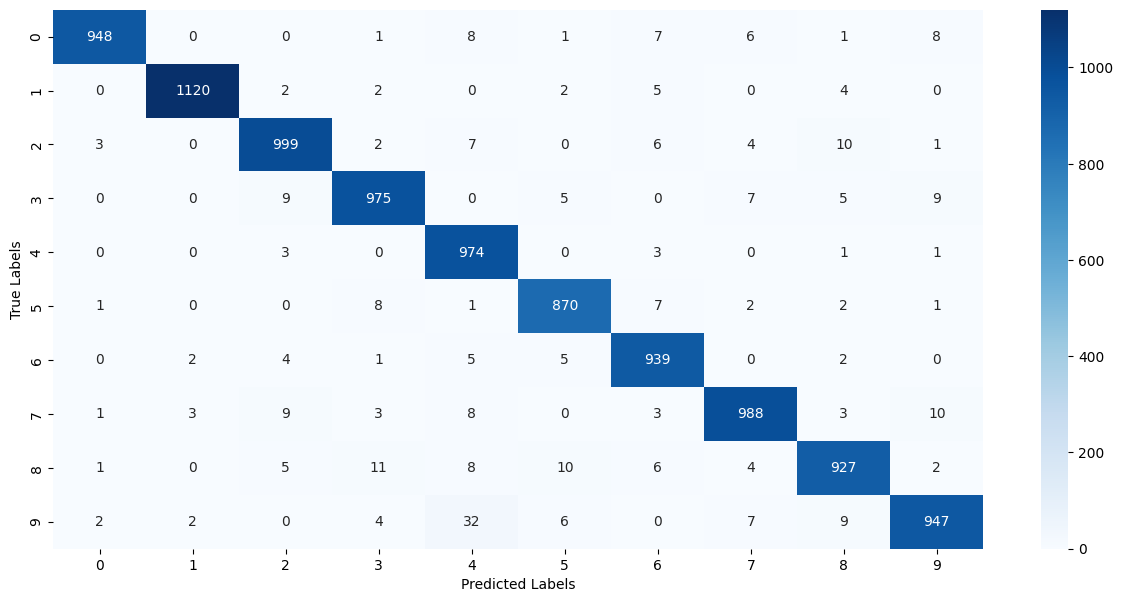

In [29]:
plt.figure(figsize=(15,7))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')

Building the predictive system

In [30]:
plt.imsave('MNIST_digit.png', X_test[0], cmap='gray')

In [31]:
input_image = cv2.imread('MNIST_digit.png')

In [32]:
type(input_image)

numpy.ndarray

In [33]:
input_image

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(28, 28, 3), dtype=uint8)

In [34]:
input_image.shape

(28, 28, 3)

In [35]:
grayscaled = cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)

In [36]:
grayscaled.shape

(28, 28)

In [37]:
scaled_input = grayscaled /255

In [38]:
reshaped_image = np.reshape(scaled_input, [1,28,28])

In [40]:
prob = model.predict(reshaped_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


In [41]:
np.argmax(prob)

np.int64(7)

In [42]:
Y_test[0]

np.uint8(7)